In [1]:
# Cell 1: Install dependencies
# ============================================================
!pip install torch-geometric -q

import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

import torch_geometric
print(f"PyG: {torch_geometric.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128, CUDA: True
PyG: 2.7.0


In [2]:
# Cell 2: Imports
# ============================================================
import json
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 3: Upload dataset to Colab
# ============================================================
# Option A: Upload a zip of all scenario JSONs
from google.colab import files
import zipfile

print("Upload a .zip file containing all scenario_XXXX.json files:")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('data/')

# Find all JSON files recursively
json_files = sorted(glob.glob('data/**/*.json', recursive=True))
print(f"Found {len(json_files)} scenario files")

Upload a .zip file containing all scenario_XXXX.json files:


Saving dataset.zip to dataset (1).zip
Found 1000 scenario files


In [4]:
# Cell 4: Constants & Encoding Maps
# ============================================================
NUM_ZONES = 6
CAMS_PER_ZONE = 10

# Graph node indices
# 0-5: zones, 6: core_router, 7: edge1, 8: edge2, 9: edge3, 10: cloud
NODE_ZONE_START = 0
NODE_CORE = 6
NODE_EDGE1 = 7
NODE_EDGE2 = 8
NODE_EDGE3 = 9
NODE_CLOUD = 10
NUM_NODES = 11

# Encoding maps
MODEL_TYPE_MAP = {'lightweight': 0, 'medium': 1, 'heavy': 2}
PROC_LOC_MAP = {'edge1': 0, 'edge2': 1, 'edge3': 2, 'cloud': 3}
PROC_LOC_TO_NODE = {'edge1': NODE_EDGE1, 'edge2': NODE_EDGE2,
                    'edge3': NODE_EDGE3, 'cloud': NODE_CLOUD}

# Network capacity constants (from simulation.cc)
LINK_CAM_TO_SWITCH = 30.0   # Mbps per camera link
LINK_SWITCH_TO_CORE = 100.0 # Mbps per zone-switch → core
LINK_CORE_TO_EDGE = 150.0   # Mbps per core → edge server
LINK_CORE_TO_CLOUD = 80.0   # Mbps core → cloud

# Target metric names
TARGET_NAMES = ['throughput_mbps', 'packet_loss_rate', 'avg_delay_ms', 'jitter_ms']

In [5]:
# Cell 4: Constants & Encoding Maps
# ============================================================
NUM_ZONES = 6
CAMS_PER_ZONE = 10

# Graph node indices
# 0-5: zones, 6: core_router, 7: edge1, 8: edge2, 9: edge3, 10: cloud
NODE_ZONE_START = 0
NODE_CORE = 6
NODE_EDGE1 = 7
NODE_EDGE2 = 8
NODE_EDGE3 = 9
NODE_CLOUD = 10
NUM_NODES = 11

# Encoding maps
MODEL_TYPE_MAP = {'lightweight': 0, 'medium': 1, 'heavy': 2}
PROC_LOC_MAP = {'edge1': 0, 'edge2': 1, 'edge3': 2, 'cloud': 3}
PROC_LOC_TO_NODE = {'edge1': NODE_EDGE1, 'edge2': NODE_EDGE2,
                    'edge3': NODE_EDGE3, 'cloud': NODE_CLOUD}

# Network capacity constants (from simulation.cc)
LINK_CAM_TO_SWITCH = 30.0   # Mbps per camera link
LINK_SWITCH_TO_CORE = 100.0 # Mbps per zone-switch → core
LINK_CORE_TO_EDGE = 150.0   # Mbps per core → edge server
LINK_CORE_TO_CLOUD = 80.0   # Mbps core → cloud

# Target metric names
TARGET_NAMES = ['throughput_mbps', 'packet_loss_rate', 'avg_delay_ms', 'jitter_ms']

In [6]:
# Cell 5: Flow-to-Zone Aggregation
# ============================================================
def aggregate_flows_to_zones(flows):
    """Aggregate 60 per-camera flows into 6 zone-level QoS targets using mean."""
    zone_targets = np.zeros((NUM_ZONES, 4))

    for z in range(NUM_ZONES):
        zone_flows = [f for f in flows if f.get('zone_id') == z
                      and 'throughput_mbps' in f]  # skip incomplete flows

        if len(zone_flows) == 0:
            # This shouldn't happen with valid data
            print(f"  WARNING: zone {z} has no valid flows!")
            continue

        zone_targets[z, 0] = np.mean([f['throughput_mbps'] for f in zone_flows])
        zone_targets[z, 1] = np.mean([f['packet_loss_rate'] for f in zone_flows])
        zone_targets[z, 2] = np.mean([f['avg_delay_ms'] for f in zone_flows])
        zone_targets[z, 3] = np.mean([f['jitter_ms'] for f in zone_flows])

    return zone_targets

In [7]:
# Cell 6: Build Graph from Scenario JSON
# ============================================================
def scenario_to_graph(scenario):
    """
    Build a PyG Data object from one scenario JSON.

    Graph structure (11 nodes):
      Nodes 0-5:  Zone nodes (one per zone)
      Node 6:     Core router
      Nodes 7-9:  Edge servers (edge1, edge2, edge3)
      Node 10:    Cloud server

    Edges:
      - Zone → Core (all 6 zones connect to core)
      - Core → Processing destination (edge1/2/3 or cloud)
      - Reverse edges for message passing

    Zone node features (10 dims):
      [bitrate, priority_onehot(3), model_type_onehot(3),
       zone_total_load/switch_capacity, bg_traffic_norm, is_zone=1]

    Infra node features (10 dims):
      [total_incoming_load/capacity, num_zones_connected, bg_traffic_norm,
       link_capacity_norm, is_core, is_edge, is_cloud, 0, 0, 0]
    """
    inp = scenario['input']
    zones = sorted(inp['zones'], key=lambda z: z['zone_id'])
    bg_traffic = inp['background_traffic_mbps']

    # --- Compute load on each infrastructure node ---
    # How much traffic each processing location receives
    load_on_node = defaultdict(float)   # node_idx -> total Mbps demand
    zones_on_node = defaultdict(int)    # node_idx -> count of zones
    for zc in zones:
        dest_node = PROC_LOC_TO_NODE[zc['processing_location']]
        zone_demand = zc['bitrate_mbps'] * CAMS_PER_ZONE
        # Traffic is bottlenecked by switch→core link (100 Mbps)
        effective_demand = min(zone_demand, LINK_SWITCH_TO_CORE)
        load_on_node[dest_node] += effective_demand
        zones_on_node[dest_node] += 1
        load_on_node[NODE_CORE] += effective_demand
        zones_on_node[NODE_CORE] += 1

    # --- Build node features ---
    node_features = torch.zeros((NUM_NODES, 10), dtype=torch.float)

    # Zone nodes (0-5)
    for zc in zones:
        z = zc['zone_id']
        bitrate = zc['bitrate_mbps']
        priority = zc['priority_class']
        model = MODEL_TYPE_MAP[zc['model_type']]
        zone_total_load = bitrate * CAMS_PER_ZONE

        feat = [
            bitrate / 25.0,                             # normalized bitrate
            float(priority == 1),                       # priority one-hot
            float(priority == 2),
            float(priority == 3),
            float(model == 0),                          # model_type one-hot
            float(model == 1),
            float(model == 2),
            zone_total_load / LINK_SWITCH_TO_CORE,      # congestion ratio at switch
            bg_traffic / 20.0,                          # normalized background traffic
            1.0                                         # is_zone flag
        ]
        node_features[z] = torch.tensor(feat, dtype=torch.float)

    # Core router (node 6)
    core_total = load_on_node.get(NODE_CORE, 0.0)
    # Core handles traffic to all destinations
    total_edge_cap = LINK_CORE_TO_EDGE * 3 + LINK_CORE_TO_CLOUD
    node_features[NODE_CORE] = torch.tensor([
        core_total / total_edge_cap,    # load ratio
        float(zones_on_node.get(NODE_CORE, 0)) / NUM_ZONES,
        bg_traffic / 20.0,
        total_edge_cap / 1000.0,        # capacity normalized
        1.0, 0.0, 0.0,                 # is_core, is_edge, is_cloud
        0.0, 0.0, 0.0
    ], dtype=torch.float)

    # Edge servers (nodes 7, 8, 9)
    for i, node_idx in enumerate([NODE_EDGE1, NODE_EDGE2, NODE_EDGE3]):
        load = load_on_node.get(node_idx, 0.0)
        n_zones = zones_on_node.get(node_idx, 0)
        node_features[node_idx] = torch.tensor([
            load / LINK_CORE_TO_EDGE,       # load ratio
            float(n_zones) / NUM_ZONES,
            bg_traffic / 20.0,
            LINK_CORE_TO_EDGE / 1000.0,
            0.0, 1.0, 0.0,                 # is_core, is_edge, is_cloud
            0.0, 0.0, 0.0
        ], dtype=torch.float)

    # Cloud server (node 10)
    cloud_load = load_on_node.get(NODE_CLOUD, 0.0)
    cloud_zones = zones_on_node.get(NODE_CLOUD, 0)
    node_features[NODE_CLOUD] = torch.tensor([
        cloud_load / LINK_CORE_TO_CLOUD,   # load ratio (can be > 1 = congested)
        float(cloud_zones) / NUM_ZONES,
        bg_traffic / 20.0,
        LINK_CORE_TO_CLOUD / 1000.0,
        0.0, 0.0, 1.0,                     # is_core, is_edge, is_cloud
        0.0, 0.0, 0.0
    ], dtype=torch.float)

    # --- Build edges ---
    src_list = []
    dst_list = []
    edge_attr_list = []

    for zc in zones:
        z = zc['zone_id']
        dest_node = PROC_LOC_TO_NODE[zc['processing_location']]
        zone_demand = zc['bitrate_mbps'] * CAMS_PER_ZONE

        # Zone → Core
        src_list.extend([z, NODE_CORE])  # bidirectional
        dst_list.extend([NODE_CORE, z])
        cap_ratio = min(zone_demand, LINK_SWITCH_TO_CORE) / LINK_SWITCH_TO_CORE
        edge_attr_list.extend([
            [cap_ratio, LINK_SWITCH_TO_CORE / 1000.0],
            [cap_ratio, LINK_SWITCH_TO_CORE / 1000.0]
        ])

        # Core → Processing destination
        if dest_node == NODE_CLOUD:
            link_cap = LINK_CORE_TO_CLOUD
        else:
            link_cap = LINK_CORE_TO_EDGE

        total_on_link = load_on_node.get(dest_node, 0.0) + bg_traffic
        link_ratio = total_on_link / link_cap

        src_list.extend([NODE_CORE, dest_node])  # bidirectional
        dst_list.extend([dest_node, NODE_CORE])
        edge_attr_list.extend([
            [link_ratio, link_cap / 1000.0],
            [link_ratio, link_cap / 1000.0]
        ])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float)

    # --- Build targets (zone-level) ---
    flows = scenario['output']['flows']
    zone_targets = aggregate_flows_to_zones(flows)
    y = torch.tensor(zone_targets, dtype=torch.float)  # shape: [6, 4]

    # --- Zone mask (which nodes are zones, for extracting predictions) ---
    zone_mask = torch.zeros(NUM_NODES, dtype=torch.bool)
    zone_mask[:NUM_ZONES] = True

    data = Data(
        x=node_features,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        zone_mask=zone_mask
    )
    data.scenario_id = scenario['scenario_id']

    return data

In [8]:
# Cell 7: Load all scenarios and build dataset
# ============================================================
all_graphs = []
skipped = 0

for fpath in json_files:
    try:
        with open(fpath, 'r') as f:
            scenario = json.load(f)

        # Validate: need both input and output
        if 'input' not in scenario or 'output' not in scenario:
            skipped += 1
            continue
        if 'flows' not in scenario['output']:
            skipped += 1
            continue

        # Check that flows have QoS data
        valid_flows = [f for f in scenario['output']['flows']
                       if 'throughput_mbps' in f]
        if len(valid_flows) < NUM_ZONES * CAMS_PER_ZONE * 0.5:  # need at least 50%
            skipped += 1
            continue

        graph = scenario_to_graph(scenario)
        all_graphs.append(graph)
    except Exception as e:
        print(f"Error processing {fpath}: {e}")
        skipped += 1

print(f"Successfully loaded: {len(all_graphs)} graphs")
print(f"Skipped: {skipped}")
print(f"\nSample graph: {all_graphs[0]}")
print(f"  Nodes: {all_graphs[0].x.shape}")
print(f"  Edges: {all_graphs[0].edge_index.shape}")
print(f"  Edge attr: {all_graphs[0].edge_attr.shape}")
print(f"  Targets (y): {all_graphs[0].y.shape}")

Successfully loaded: 1000 graphs
Skipped: 0

Sample graph: Data(x=[11, 10], edge_index=[2, 24], edge_attr=[24, 2], y=[6, 4], zone_mask=[11], scenario_id='scenario_0000')
  Nodes: torch.Size([11, 10])
  Edges: torch.Size([2, 24])
  Edge attr: torch.Size([24, 2])
  Targets (y): torch.Size([6, 4])


In [9]:
# Cell 8: Target normalization (computed on TRAIN set only)
# ============================================================

# Split indices first
indices = list(range(len(all_graphs)))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# Compute normalization from TRAIN only
train_targets = torch.stack([all_graphs[i].y for i in train_idx])  # [N_train, 6, 4]
train_flat = train_targets.reshape(-1, 4)

target_mean = train_flat.mean(dim=0)
target_std = train_flat.std(dim=0)
target_std[target_std < 1e-6] = 1.0  # avoid division by zero

print(f"\nTarget statistics (train set):")
for i, name in enumerate(TARGET_NAMES):
    print(f"  {name:>20s}: mean={target_mean[i]:.4f}, std={target_std[i]:.4f}")

# Normalize all targets
for g in all_graphs:
    g.y_raw = g.y.clone()  # keep raw for evaluation
    g.y = (g.y - target_mean) / target_std

# Build data loaders
train_graphs = [all_graphs[i] for i in train_idx]
val_graphs = [all_graphs[i] for i in val_idx]
test_graphs = [all_graphs[i] for i in test_idx]

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=64, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)

Train: 700, Val: 150, Test: 150

Target statistics (train set):
       throughput_mbps: mean=5.5115, std=2.6177
      packet_loss_rate: mean=0.4265, std=0.2923
          avg_delay_ms: mean=42.9524, std=150.4257
             jitter_ms: mean=1.5377, std=37.7915


In [10]:
# Cell 9: GNN Model
# ============================================================
class AirportGNN(nn.Module):
    """
    Simple GNN for zone-level QoS prediction.

    Architecture:
      - 3 GATConv layers with residual connections
      - Extract zone nodes (indices 0-5)
      - Per-zone MLP head → 4 QoS outputs

    Sized appropriately for ~1000 samples (~50K params vs 774K before).
    """

    def __init__(self, in_channels=10, edge_dim=2, hidden=64, heads=4,
                 out_channels=4, dropout=0.2):
        super().__init__()

        self.dropout = dropout

        # Input projection
        self.input_proj = nn.Linear(in_channels, hidden)

        # GAT layers
        self.conv1 = GATConv(hidden, hidden // heads, heads=heads,
                             edge_dim=edge_dim, dropout=dropout)
        self.norm1 = nn.LayerNorm(hidden)

        self.conv2 = GATConv(hidden, hidden // heads, heads=heads,
                             edge_dim=edge_dim, dropout=dropout)
        self.norm2 = nn.LayerNorm(hidden)

        self.conv3 = GATConv(hidden, hidden // heads, heads=heads,
                             edge_dim=edge_dim, dropout=dropout)
        self.norm3 = nn.LayerNorm(hidden)

        # Zone prediction head
        self.zone_head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, out_channels)
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        batch = data.batch if hasattr(data, 'batch') and data.batch is not None \
                else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        # Input projection
        x = F.relu(self.input_proj(x))

        # GAT block 1 (with residual)
        residual = x
        x = self.conv1(x, edge_index, edge_attr)
        x = F.elu(x)
        x = self.norm1(x + residual)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GAT block 2 (with residual)
        residual = x
        x = self.conv2(x, edge_index, edge_attr)
        x = F.elu(x)
        x = self.norm2(x + residual)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GAT block 3 (with residual)
        residual = x
        x = self.conv3(x, edge_index, edge_attr)
        x = F.elu(x)
        x = self.norm3(x + residual)

        # Extract only zone nodes (first 6 nodes per graph in the batch)
        zone_mask = data.zone_mask  # [total_nodes_in_batch]
        zone_features = x[zone_mask]  # [batch_size * 6, hidden]

        # Predict QoS per zone
        predictions = self.zone_head(zone_features)  # [batch_size * 6, 4]

        # Reshape to [batch_size, 6, 4]
        batch_size = batch.max().item() + 1
        predictions = predictions.view(batch_size, NUM_ZONES, 4)

        return predictions

In [11]:
# Cell 10: Training setup
# ============================================================
model = AirportGNN(
    in_channels=10,
    edge_dim=2,
    hidden=64,
    heads=4,
    out_channels=4,
    dropout=0.2
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} total, {trainable_params:,} trainable")
print(f"Train samples: {len(train_graphs)}, ratio: {len(train_graphs)/trainable_params:.1f} samples/param")
print(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)

EPOCHS = 300
PATIENCE = 40

Model parameters: 20,900 total, 20,900 trainable
Train samples: 700, ratio: 0.0 samples/param
AirportGNN(
  (input_proj): Linear(in_features=10, out_features=64, bias=True)
  (conv1): GATConv(64, 16, heads=4)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (conv2): GATConv(64, 16, heads=4)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (conv3): GATConv(64, 16, heads=4)
  (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (zone_head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [12]:
# Cell 11: Training loop
# ============================================================
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    n_samples = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch)                    # [B, 6, 4]
        target = batch.y.view(-1, NUM_ZONES, 4)  # [B, 6, 4]

        loss = F.huber_loss(pred, target, delta=1.0)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * pred.size(0)
        n_samples += pred.size(0)

    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    n_samples = 0
    all_preds = []
    all_targets = []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        target = batch.y.view(-1, NUM_ZONES, 4)

        loss = F.huber_loss(pred, target, delta=1.0)
        total_loss += loss.item() * pred.size(0)
        n_samples += pred.size(0)

        # Denormalize for metrics
        pred_raw = pred.cpu() * target_std + target_mean
        target_raw = batch.y_raw.view(-1, NUM_ZONES, 4).cpu()

        all_preds.append(pred_raw)
        all_targets.append(target_raw)

    avg_loss = total_loss / n_samples
    all_preds = torch.cat(all_preds, dim=0).numpy()     # [N, 6, 4]
    all_targets = torch.cat(all_targets, dim=0).numpy()

    # Per-metric R² and MAE across all zones
    metrics = {}
    for i, name in enumerate(TARGET_NAMES):
        p = all_preds[:, :, i].flatten()
        t = all_targets[:, :, i].flatten()
        metrics[f'{name}_r2'] = r2_score(t, p)
        metrics[f'{name}_mae'] = mean_absolute_error(t, p)

    return avg_loss, metrics, all_preds, all_targets


# --- Training ---
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_r2': []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss, val_metrics, _, _ = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    avg_r2 = np.mean([val_metrics[f'{n}_r2'] for n in TARGET_NAMES])
    history['val_r2'].append(avg_r2)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"R²: {avg_r2:.4f} | LR: {scheduler.get_last_lr()[0]:.6f} | "
              f"Pat: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch   1 | Train: 0.2360 | Val: 0.2225 | R²: 0.0537 | LR: 0.003000 | Pat: 0/40
Epoch  20 | Train: 0.1774 | Val: 0.1640 | R²: 0.1735 | LR: 0.002967 | Pat: 0/40
Epoch  40 | Train: 0.1747 | Val: 0.1649 | R²: 0.1748 | LR: 0.002871 | Pat: 1/40
Epoch  60 | Train: 0.1738 | Val: 0.1641 | R²: 0.1707 | LR: 0.002714 | Pat: 21/40

Early stopping at epoch 79

Best validation loss: 0.1625


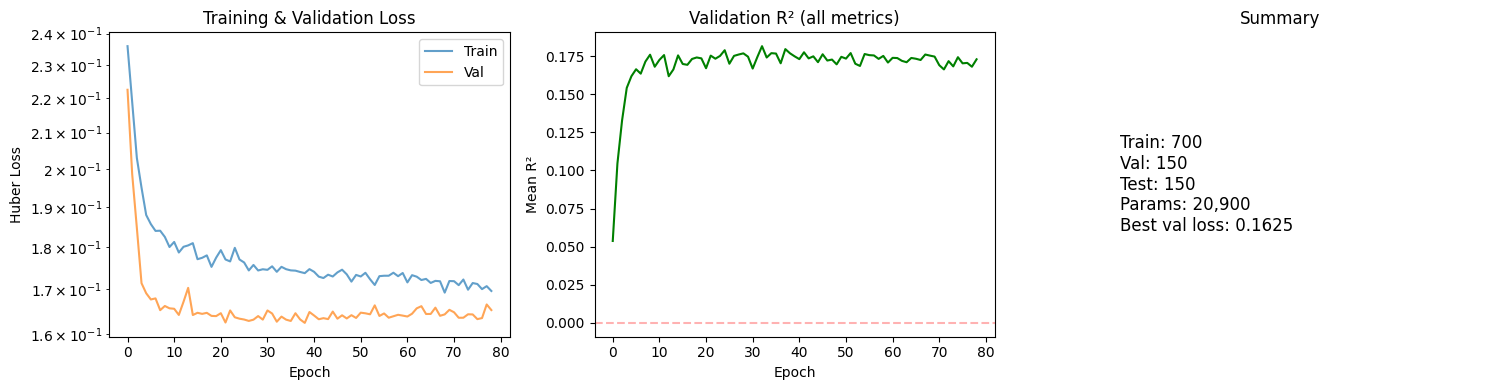

In [13]:
# Cell 12: Plot training history
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', alpha=0.7)
axes[0].plot(history['val_loss'], label='Val', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].plot(history['val_r2'], color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean R²')
axes[1].set_title('Validation R² (all metrics)')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.3)

axes[2].text(0.1, 0.5, f"Train: {len(train_graphs)}\n"
             f"Val: {len(val_graphs)}\nTest: {len(test_graphs)}\n"
             f"Params: {total_params:,}\n"
             f"Best val loss: {best_val_loss:.4f}",
             transform=axes[2].transAxes, fontsize=12, verticalalignment='center')
axes[2].set_title('Summary')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Cell 13: Test set evaluation
# ============================================================
model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_metrics, test_preds, test_targets = evaluate(model, test_loader)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"{'Metric':>20s}  {'R²':>8s}  {'MAE':>10s}")
print("-" * 42)
for name in TARGET_NAMES:
    r2 = test_metrics[f'{name}_r2']
    mae = test_metrics[f'{name}_mae']
    print(f"{name:>20s}  {r2:>8.4f}  {mae:>10.4f}")

avg_r2 = np.mean([test_metrics[f'{n}_r2'] for n in TARGET_NAMES])
print("-" * 42)
print(f"{'Average':>20s}  {avg_r2:>8.4f}")

TEST SET RESULTS
              Metric        R²         MAE
------------------------------------------
     throughput_mbps    0.2290      1.8763
    packet_loss_rate    0.4518      0.1793
        avg_delay_ms   -0.0009     26.1832
           jitter_ms   -0.0040      3.9548
------------------------------------------
             Average    0.1690


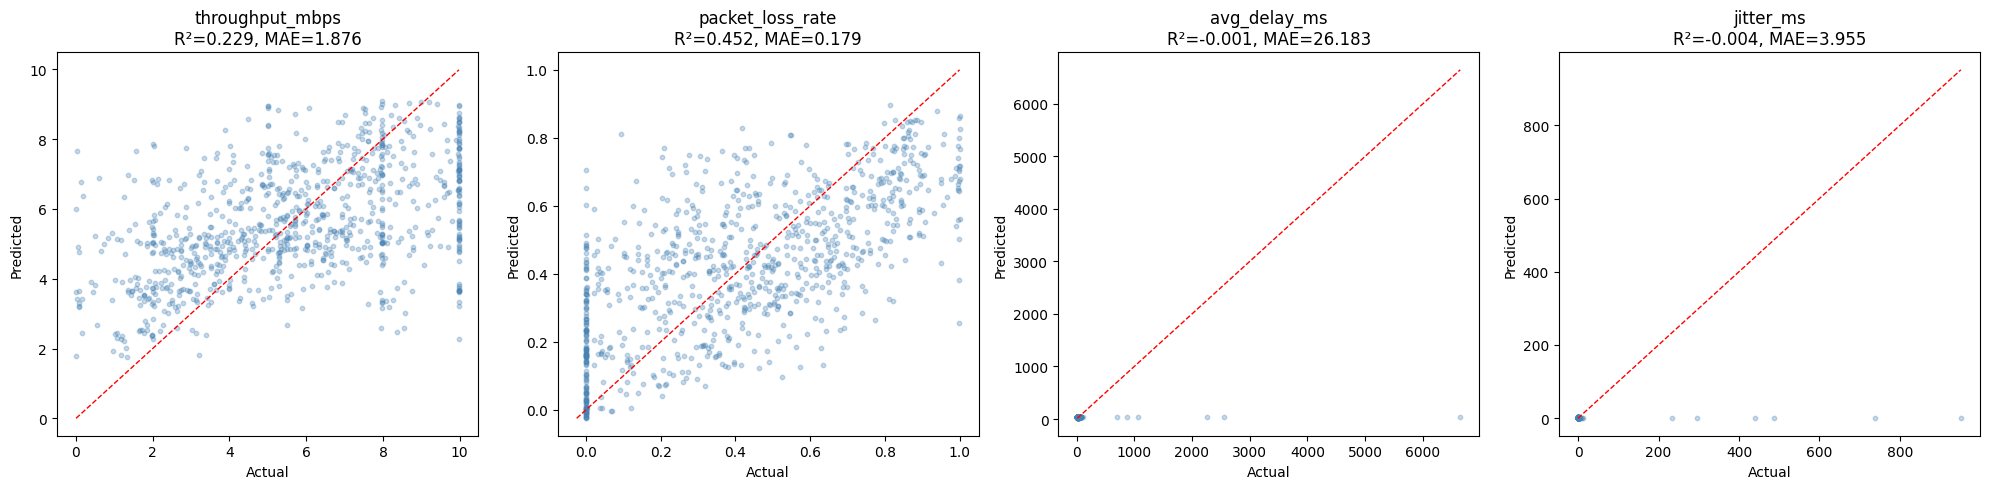

In [15]:
# Cell 14: Per-metric scatter plots (predicted vs actual)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, name in enumerate(TARGET_NAMES):
    ax = axes[i]
    pred = test_preds[:, :, i].flatten()
    true = test_targets[:, :, i].flatten()

    ax.scatter(true, pred, alpha=0.3, s=10, color='steelblue')

    # Perfect prediction line
    mn = min(true.min(), pred.min())
    mx = max(true.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1)

    r2 = test_metrics[f'{name}_r2']
    mae = test_metrics[f'{name}_mae']
    ax.set_title(f'{name}\nR²={r2:.3f}, MAE={mae:.3f}')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('test_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Cell 15: Inference function for new scenarios
# ============================================================
def predict_scenario(model, scenario_input, target_mean, target_std):
    """
    Predict zone-level QoS for a new scenario.

    Args:
        model: trained AirportGNN
        scenario_input: dict with keys 'background_traffic_mbps', 'zones'
                        (same format as the 'input' field in scenario JSONs)
        target_mean, target_std: normalization tensors

    Returns:
        dict: zone_id -> {throughput_mbps, packet_loss_rate, avg_delay_ms, jitter_ms}
    """
    model.eval()

    # Build a dummy scenario with fake output (targets unused at inference)
    dummy_scenario = {
        'scenario_id': 'inference',
        'input': scenario_input,
        'output': {
            'flows': [
                {
                    'zone_id': cam_idx // CAMS_PER_ZONE,
                    'cam_index': cam_idx,
                    'cam_in_zone': cam_idx % CAMS_PER_ZONE,
                    'throughput_mbps': 0.0,
                    'packet_loss_rate': 0.0,
                    'avg_delay_ms': 0.0,
                    'jitter_ms': 0.0,
                }
                for cam_idx in range(NUM_ZONES * CAMS_PER_ZONE)
            ],
            'scenario_id': 'inference',
            'simulation_time': scenario_input.get('simulation_time', 10.0),
            'total_flows': NUM_ZONES * CAMS_PER_ZONE
        }
    }

    graph = scenario_to_graph(dummy_scenario).to(device)
    # Add batch dimension
    graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long, device=device)

    with torch.no_grad():
        pred_norm = model(graph)  # [1, 6, 4]
        pred = pred_norm.cpu() * target_std + target_mean
        pred = pred.squeeze(0).numpy()  # [6, 4]

    results = {}
    for z in range(NUM_ZONES):
        results[z] = {
            'throughput_mbps': float(pred[z, 0]),
            'packet_loss_rate': float(np.clip(pred[z, 1], 0.0, 1.0)),
            'avg_delay_ms': float(max(pred[z, 2], 0.0)),
            'jitter_ms': float(max(pred[z, 3], 0.0)),
        }

    return results


# --- Test inference with the first scenario's input ---
with open(json_files[0]) as f:
    sample = json.load(f)

predictions = predict_scenario(model, sample['input'], target_mean, target_std)

print("INFERENCE EXAMPLE")
print(f"Scenario: {sample['input']['scenario_id']}")
print(f"Background traffic: {sample['input']['background_traffic_mbps']} Mbps")
print()
print(f"{'Zone':>4} {'Throughput':>12} {'Loss Rate':>12} {'Delay(ms)':>12} {'Jitter(ms)':>12}")
print("-" * 56)
for z in range(NUM_ZONES):
    p = predictions[z]
    print(f"{z:>4} {p['throughput_mbps']:>12.3f} {p['packet_loss_rate']:>12.4f} "
          f"{p['avg_delay_ms']:>12.3f} {p['jitter_ms']:>12.4f}")

# Compare with actual values
print(f"\n{'--- Actual (from simulation) ---':^56}")
actual = aggregate_flows_to_zones(sample['output']['flows'])
print(f"{'Zone':>4} {'Throughput':>12} {'Loss Rate':>12} {'Delay(ms)':>12} {'Jitter(ms)':>12}")
print("-" * 56)
for z in range(NUM_ZONES):
    print(f"{z:>4} {actual[z,0]:>12.3f} {actual[z,1]:>12.4f} "
          f"{actual[z,2]:>12.3f} {actual[z,3]:>12.4f}")

INFERENCE EXAMPLE
Scenario: scenario_0000
Background traffic: 4.4 Mbps

Zone   Throughput    Loss Rate    Delay(ms)   Jitter(ms)
--------------------------------------------------------
   0        6.634       0.1017       31.940       0.0000
   1        5.305       0.1151       30.572       0.0000
   2        6.028       0.1694       31.635       0.0000
   3        4.867       0.1018       30.243       0.0000
   4        6.021       0.1060       30.568       0.0000
   5        6.463       0.1165       31.638       0.0000

            --- Actual (from simulation) ---            
Zone   Throughput    Loss Rate    Delay(ms)   Jitter(ms)
--------------------------------------------------------
   0        7.756       0.0000       28.549       0.0000
   1        6.123       0.0000       29.566       0.0025
   2        3.922       0.4993       44.915       0.0388
   3        5.203       0.0000       16.681       0.0371
   4        7.143       0.0000       28.701       0.0635
   5        4.0

In [17]:
# Cell 16: Save model + normalization for deployment
# ============================================================
torch.save({
    'model_state_dict': model.state_dict(),
    'target_mean': target_mean,
    'target_std': target_std,
    'model_config': {
        'in_channels': 10,
        'edge_dim': 2,
        'hidden': 64,
        'heads': 4,
        'out_channels': 4,
        'dropout': 0.2,
    }
}, 'airport_gnn_checkpoint.pt')

print("Saved: airport_gnn_checkpoint.pt")

# Download from Colab
from google.colab import files
files.download('airport_gnn_checkpoint.pt')
files.download('training_history.png')
files.download('test_scatter.png')

Saved: airport_gnn_checkpoint.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>